# 04 — Runs Comparison
**Skin Lesion Classification in Thermal Images**

Este notebook **carrega e compara** todos os runs já salvos em `results/runs/` — assim como `03_evaluation.ipynb`, ele não treina nada. Enquanto o notebook 03 analisa em profundidade **um** run, este agrega a métrica de AUC (nível de paciente, `metrics_cv_folds_patient.csv`) de **todos** os runs para visualizar a evolução dos experimentos e destacar melhor/pior/média por modelo.

⚠️ Os runs não são diretamente comparáveis entre si — a metodologia evoluiu (nível de frame vs. sequência, rótulo por pasta vs. biópsia, entrada temporal on/off). A célula de metadados abaixo lê `train_config.json` de cada run para anotar essas diferenças automaticamente.

In [5]:
import json
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

RUNS_DIR = Path("../results/runs")

# Runs com o pipeline atual (têm train_config.json + metrics_cv_folds_patient.csv),
# ordenados cronologicamente pelo nome da pasta (timestamp).
run_dirs = sorted(
    p for p in RUNS_DIR.iterdir()
    if p.is_dir()
    and (p / "train_config.json").exists()
    and (p / "metrics_cv_folds_patient.csv").exists()
)
print(f"{len(run_dirs)} runs encontrados:")
for p in run_dirs:
    print(" -", p.name)

6 runs encontrados:
 - 20260713_124039
 - 20260713_182250
 - 20260714_143040
 - 20260714_184810
 - 20260715_112444
 - 20260715_roi_rich_ensemble


In [6]:
def run_tag(config: dict) -> str:
    """Resume as opções metodológicas do run que afetam comparabilidade."""
    level = config.get("classical_level", "frame")
    label = config.get("label_source", "folder")
    temporal = config.get("temporal_mode", "off")
    tag = f"{level} · {label}"
    if temporal != "off":
        tag += f" · temporal={temporal}"
    if config.get("ensemble"):
        tag += " · ensemble"
    return tag


records = []
run_meta = {}
for run_dir in run_dirs:
    with open(run_dir / "train_config.json") as f:
        config = json.load(f)
    run_meta[run_dir.name] = run_tag(config)

    df = pd.read_csv(run_dir / "metrics_cv_folds_patient.csv")
    grouped = df.groupby("model")["auc_roc"].agg(["mean", "std"]).reset_index()
    for _, row in grouped.iterrows():
        records.append({
            "run": run_dir.name,
            "model": row["model"],
            "mean_auc": row["mean"],
            "std_auc": row["std"] if pd.notna(row["std"]) else 0.0,
        })

runs_auc = pd.DataFrame(records)
runs_auc

,run,model,mean_auc,std_auc
0,20260713_124039,Random Forest,0.714950,0.073684
1,20260713_124039,ResNet18,0.706844,0.069351
2,20260713_124039,SVM,0.709357,0.076302
3,20260713_124039,ThermalCNN,0.611969,0.083142
4,20260713_182250,Random Forest,0.694016,0.066966
5,20260713_182250,ResNet18,0.673022,0.067027
6,20260713_182250,SVM,0.664134,0.055496
7,20260713_182250,ThermalCNN,0.624568,0.085369
8,20260714_143040,Random Forest,0.632338,0.080197
9,20260714_143040,ResNet18,0.633573,0.062204


## Evolução da AUC (nível de paciente) por modelo, entre runs

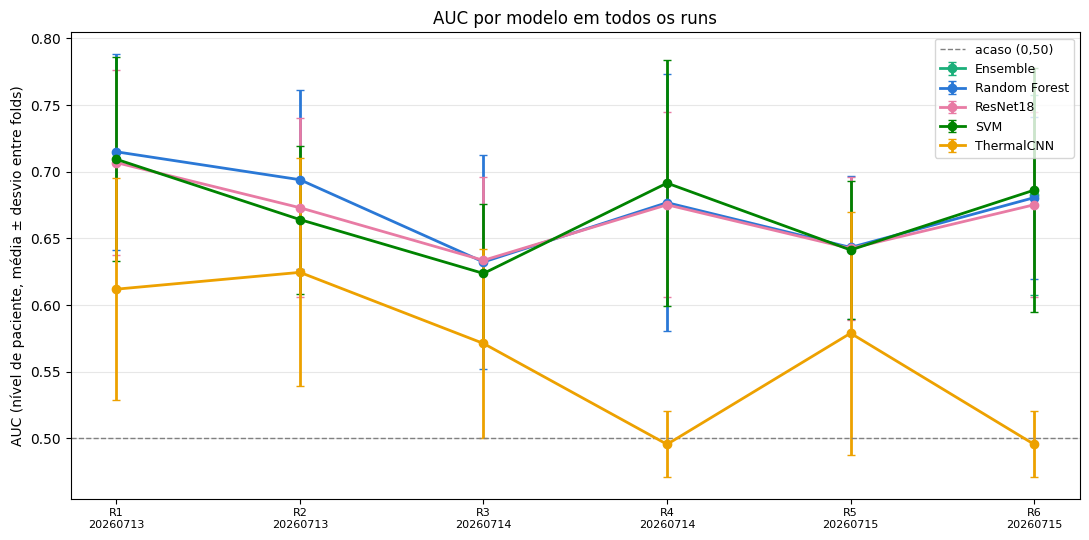


Legenda dos runs (R1..Rn):
  R1: 20260713_124039  —  frame · folder
  R2: 20260713_182250  —  frame · folder
  R3: 20260714_143040  —  frame · biopsy · temporal=context
  R4: 20260714_184810  —  sequence · biopsy
  R5: 20260715_112444  —  sequence · folder
  R6: 20260715_roi_rich_ensemble  —  sequence · biopsy · ensemble


In [7]:
run_order = [p.name for p in run_dirs]
run_labels = [f"R{i+1}\n{name[:8]}" for i, name in enumerate(run_order)]

models = sorted(runs_auc["model"].unique())
colors = {
    "Random Forest": "#2a78d6",
    "SVM": "#008300",
    "ResNet18": "#e87ba4",
    "ThermalCNN": "#eda100",
    "Ensemble": "#1baf7a",
}

fig, ax = plt.subplots(figsize=(11, 5.5))
for model in models:
    sub = runs_auc[runs_auc["model"] == model].set_index("run").reindex(run_order)
    x = [i for i, v in enumerate(sub["mean_auc"]) if pd.notna(v)]
    y = sub["mean_auc"].dropna().values
    yerr = sub["std_auc"].dropna().values
    color = colors.get(model, None)
    ax.errorbar(x, y, yerr=yerr, marker="o", capsize=3, label=model, color=color, linewidth=2)

ax.axhline(0.50, color="gray", linestyle="--", linewidth=1, label="acaso (0,50)")
ax.set_xticks(range(len(run_order)))
ax.set_xticklabels(run_labels, fontsize=8)
ax.set_ylabel("AUC (nível de paciente, média ± desvio entre folds)")
ax.set_title("AUC por modelo em todos os runs")
ax.legend(loc="upper right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

print("\nLegenda dos runs (R1..Rn):")
for i, name in enumerate(run_order):
    print(f"  R{i+1}: {name}  —  {run_meta[name]}")

## Melhor, pior e média por modelo

In [8]:
summary_rows = []
for model in models:
    sub = runs_auc[runs_auc["model"] == model]
    best = sub.loc[sub["mean_auc"].idxmax()]
    worst = sub.loc[sub["mean_auc"].idxmin()]
    summary_rows.append({
        "model": model,
        "n_runs": len(sub),
        "best_run": best["run"],
        "best_auc": round(best["mean_auc"], 4),
        "worst_run": worst["run"],
        "worst_auc": round(worst["mean_auc"], 4),
        "mean_auc_across_runs": round(sub["mean_auc"].mean(), 4),
    })

summary = pd.DataFrame(summary_rows).sort_values("mean_auc_across_runs", ascending=False)
summary

,model,n_runs,best_run,best_auc,worst_run,worst_auc,mean_auc_across_runs
0,Ensemble,1,20260715_roi_rich_ensemble,0.6826,20260715_roi_rich_ensemble,0.6826,0.6826
1,Random Forest,6,20260713_124039,0.7149,20260714_143040,0.6323,0.6737
3,SVM,6,20260713_124039,0.7094,20260714_143040,0.6238,0.6694
2,ResNet18,6,20260713_124039,0.7068,20260714_143040,0.6336,0.6677
4,ThermalCNN,6,20260713_182250,0.6246,20260714_184810,0.4956,0.5630


**Nota de leitura**: o run com maior AUC nominal não é necessariamente o mais confiável — runs mais antigos avaliam no nível de frame (não de sequência/paciente) e usam rótulos por pasta (heurística), o que infla a AUC frente ao pipeline atual (nível de sequência, rótulos por biópsia, `pooled_auc_ci` com IC 95% bootstrap — ver `03_evaluation.ipynb`, Seção 6, para a estimativa honesta do run mais recente).

## Tabela única para envio (AUC pooled atual + melhor/pior/média histórico)

Consolida em uma única tabela: a **AUC pooled com IC 95% bootstrap** (a estimativa mais confiável, calculada sobre as predições por sequência do run mais recente) ao lado do **melhor, pior e média** da AUC por paciente entre todos os runs já executados — pronta para copiar e enviar ao orientador.

In [9]:
import glob
import os

from src.evaluate import pooled_auc_ci
from src.pipeline import FILE_SLUG

# Run mais recente com o pipeline atual = a estimativa "oficial" a reportar.
latest_run = run_dirs[-1]
print(f"AUC pooled calculada sobre: {latest_run.name}")

slug_to_display = {slug: name for name, slug in FILE_SLUG.items()}

pooled_by_model = {}
for f in sorted(glob.glob(str(latest_run / "predictions_seq_*.npz"))):
    slug = os.path.basename(f).replace("predictions_seq_", "").replace(".npz", "")
    data = np.load(f)
    y_true, y_prob = data["y_true"], data["y_prob"]
    if y_prob.ndim == 2:
        y_prob = y_prob[:, 1]
    auc, lo, hi = pooled_auc_ci(y_true, y_prob)
    model = slug_to_display.get(slug, slug)
    pooled_by_model[model] = {"pooled_auc": auc, "ci_low": lo, "ci_high": hi}

final_rows = []
for _, row in summary.iterrows():
    model = row["model"]
    pooled = pooled_by_model.get(model)
    final_rows.append({
        "Modelo": model,
        "AUC pooled (atual)": round(pooled["pooled_auc"], 3) if pooled else None,
        "IC 95%": f'[{pooled["ci_low"]:.3f} \u2013 {pooled["ci_high"]:.3f}]' if pooled else "-",
        "Melhor": row["best_auc"],
        "Pior": row["worst_auc"],
        "Media (n exec.)": f'{row["mean_auc_across_runs"]:.4f} (n={row["n_runs"]})',
    })

final_table = pd.DataFrame(final_rows).sort_values("AUC pooled (atual)", ascending=False)
final_table

AUC pooled calculada sobre: 20260715_roi_rich_ensemble


,Modelo,AUC pooled (atual),IC 95%,Melhor,Pior,Media (n exec.)
1,Random Forest,0.660,[0.574 – 0.743],0.7149,0.6323,0.6737 (n=6)
0,Ensemble,0.652,[0.563 – 0.737],0.6826,0.6826,0.6826 (n=1)
3,ResNet18,0.648,[0.558 – 0.732],0.7068,0.6336,0.6677 (n=6)
2,SVM,0.640,[0.550 – 0.725],0.7094,0.6238,0.6694 (n=6)
4,ThermalCNN,0.483,[0.392 – 0.578],0.6246,0.4956,0.5630 (n=6)


**Como ler**: *AUC pooled (atual)* é a métrica a citar no TCC — nível de sequência, IC 95% via bootstrap estratificado, sobre o run mais recente/rigoroso. *Melhor/Pior/Média* mostram a variação entre todas as execuções já feitas, incluindo runs antigos com metodologia menos rigorosa (nível de frame, rótulo por pasta) — por isso costumam ser mais altos que a AUC pooled atual e não devem ser citados como o resultado do modelo, só como contexto de robustez.

Para copiar como texto simples:

In [10]:
print(final_table.to_string(index=False))

       Modelo  AUC pooled (atual)          IC 95%  Melhor   Pior Media (n exec.)
Random Forest               0.660 [0.574 – 0.743]  0.7149 0.6323    0.6737 (n=6)
     Ensemble               0.652 [0.563 – 0.737]  0.6826 0.6826    0.6826 (n=1)
     ResNet18               0.648 [0.558 – 0.732]  0.7068 0.6336    0.6677 (n=6)
          SVM               0.640 [0.550 – 0.725]  0.7094 0.6238    0.6694 (n=6)
   ThermalCNN               0.483 [0.392 – 0.578]  0.6246 0.4956    0.5630 (n=6)
